In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
import os
os.chdir('/workdir/jz963/utils/plantcad2/results/SV_effect/outputs')

In [2]:
phyloP = pd.read_csv('Ath_Simulated_DEL_Len_1-50_withPhyloP.tsv', sep='\t', header=0)
phyloP.head()

,chr,start,end,location,mean_pcv2_large,meanPhyloP
0,1,17983,18028,1:17983-18028,-0.511375,NaN
1,1,45457,45493,1:45457-45493,-0.146789,0.293157
2,1,59366,59393,1:59366-59393,-0.603567,0.693324
3,1,60028,60057,1:60028-60057,-0.109686,0.319348
4,1,67533,67578,1:67533-67578,-0.218987,-0.099907


In [3]:
file_names = {
    'flank_5': 'Ath_Simulated_DEL_Len_1-50_score.tsv',
    'flank_10': 'Ath_Simulated_DEL_Len_1-50_score_shift_5.tsv',
    'flank_15': 'Ath_Simulated_DEL_Len_1-50_score_shift_10.tsv',
    'flank_20': 'Ath_Simulated_DEL_Len_1-50_score_shift_15.tsv',
    'flank_25': 'Ath_Simulated_DEL_Len_1-50_score_shift_20.tsv'
}

In [4]:
flank_data_dict = {}
for name, file_name in file_names.items():
    try:
        flank_data_dict[name] = pd.read_csv(file_name, sep='\t', header=0)
    except FileNotFoundError:
        print(f"Error: '{file_name}' not found. Please check the path.")
        exit()

In [5]:
def calculate_auc(current_flanks_list, phyloP_data):
    """
    Calculates the Area Under the Receiver Operating Characteristic Curve (AUC).
    """
    # and combine them horizontally.
    cols_to_combine = [df.iloc[:, 11:21] for df in current_flanks_list]
    
    combined_scores = pd.concat(cols_to_combine, axis=1)
    mean_pcv2_scores = combined_scores.mean(axis=1)

    relevant_mask = (phyloP_data['meanPhyloP'] > 1) | (phyloP_data['meanPhyloP'] < 0)
    
    filtered_scores = mean_pcv2_scores[relevant_mask] * -1
    filtered_true_labels = np.where(phyloP_data['meanPhyloP'][relevant_mask] > 1, 1, 0)
    
    if len(np.unique(filtered_true_labels)) < 2:
        print("Warning: Not enough unique classes (positive/negative) to calculate AUC.")
        return np.nan # Return NaN if AUC cannot be calculated

    auc_value = roc_auc_score(filtered_true_labels, filtered_scores)
    return auc_value

In [6]:
auc_results = {}

auc_results["Flank_5"] = calculate_auc([flank_data_dict['flank_5']], phyloP)
auc_results["Flank_10"] = calculate_auc([flank_data_dict['flank_5'],
                                           flank_data_dict['flank_10']], phyloP)
auc_results["Flank_15"] = calculate_auc([flank_data_dict['flank_5'],
                                           flank_data_dict['flank_10'],
                                           flank_data_dict['flank_15']], phyloP)
auc_results["Flank_20"] = calculate_auc([flank_data_dict['flank_5'],
                                           flank_data_dict['flank_10'],
                                           flank_data_dict['flank_15'],
                                           flank_data_dict['flank_20']], phyloP)
auc_results["Flank_25"] = calculate_auc([flank_data_dict['flank_5'],
                                           flank_data_dict['flank_10'],
                                           flank_data_dict['flank_15'],
                                           flank_data_dict['flank_20'],
                                           flank_data_dict['flank_25']], phyloP)

In [7]:
print("\nCalculated AUC values:")
for combo, auc_val in auc_results.items():
    print(f"{combo}: {auc_val:.4f}")

plot_data = pd.DataFrame({
    'Flank_Combination': list(auc_results.keys()),
    'AUC': list(auc_results.values())
})

order = ["Flank_5", "Flank_10", "Flank_15", "Flank_20", "Flank_25"]
plot_data['Flank_Combination'] = pd.Categorical(plot_data['Flank_Combination'], categories=order, ordered=True)
plot_data = plot_data.sort_values('Flank_Combination')



Calculated AUC values:
Flank_5: 0.8184
Flank_10: 0.8415
Flank_15: 0.7805
Flank_20: 0.7446
Flank_25: 0.7260


/tmp/ipykernel_1636270/3151076270.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


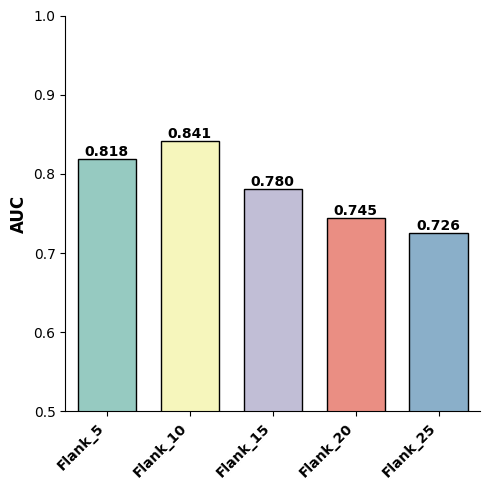

In [8]:
plt.figure(figsize=(5, 5)) 

barplot = sns.barplot(
    x='Flank_Combination',
    y='AUC',
    data=plot_data,
    palette='Set3', 
    edgecolor='black',
    width=0.7 
)

for index, row in plot_data.iterrows():
    barplot.text(
        index,
        row['AUC'],
        f"{row['AUC']:.3f}",
        color='black',
        ha="center", 
        va='bottom', 
        fontsize=10,
        fontweight='bold'
    )

plt.xlabel("", fontsize=12, fontweight='bold')
plt.ylabel("AUC", fontsize=12, fontweight='bold')

plt.ylim(0.5, 1)
plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold', color='black')
plt.yticks(fontsize=10, color='black')

plt.grid(False)
sns.despine(left=False, bottom=False) # Remove top and right spines

plt.tight_layout()
plt.savefig("../../../pipelines/SV_effect/figures/AUROC_versus_flank_region.pdf")
plt.show()